In [1]:
ds_cube.lst.isel(time=slice(0, 4)).plot(
    col="time",
    col_wrap=2,
    robust=True,
    cbar_kwargs={
        "orientation": "horizontal",
        "shrink": 0.8,
        "aspect": 40,
        "label": "Air Temperature [°K]",
    },
)
plt.show()

NameError: name 'ds_cube' is not defined

In [1]:
#TREND LINE NDVI
import numpy as np

# x values = years
x = ds_cube["year"].values

# y values = mean LST
y = mean_ndvi.values

# linear fit
slope, intercept = np.polyfit(x, y, 1)

# trend line
trend_ndvi = slope * x + intercept

NameError: name 'ds_cube' is not defined

In [2]:
print(f"Warming trend: {slope:.3f} °C per year")
print(f"Warming trend: {slope*10:.3f} °C per decade")

NameError: name 'slope' is not defined

In [ ]:
#PLOT TREND NDVI
plt.figure(figsize=(10,6))

# original data
plt.plot(x, y, marker="o", label="Mean LST")

# trend line
plt.plot(x, trend_ndvi, linestyle="--", label="Trend Line")

plt.title("Mean NDVI in Zurich (1985–2024)")
plt.xlabel("Year")
plt.ylabel("Mean NDVI")

plt.legend()
plt.grid(True)

plt.show()

In [2]:
# 1. Isolate the baseline period
baseline_lst = ds_cube.lst.sel(time= slice ("1985-01-01", "2024-01-01"))
yearly_lst = baseline_lst.groupby("time").mean()
anom_lst = ds_cube.lst.groupby("time") - yearly_lst
anom_example = anom_lst.sel(time="2012-01-01", method="nearest")
anom_example.plot(cmap="RdBu_r", vmin=-3, vmax=3, figsize=(9, 4))
plt.title("Sea Surface Temperature Anomaly (January 2016)")
plt.show()

NameError: name 'ds_cube' is not defined

In [3]:
# baseline mean over all years
baseline_lst = ds_cube.lst.sel(
    time=slice("1985-01-01", "2015-01-01")
).mean(dim="time")

# anomaly for one year
anom_2021 = ds_cube.lst.sel(time="2021-01-01") - baseline_lst

anom_2021.name = "LST anomaly"
anom_2021.attrs = {"long_name": "LST anomaly (°C)"}

anom_2021.plot(cmap="RdBu_r", vmin=-5, vmax=5)
plt.title("LST anomaly relative to 1985–2015 mean (2021)")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()

NameError: name 'ds_cube' is not defined

In [ ]:
# baseline mean over all years
baseline_lst = ds_cube.lst.sel(
    time=slice("1985-01-01", "2015-01-01")
).mean(dim="time")

# anomaly for one year
anom_2021 = ds_cube.lst.sel(time="2021-01-01") - baseline_lst

anom_2021.name = "LST anomaly"
anom_2021.attrs = {"long_name": "LST anomaly (°C)"}

anom_2021.plot(cmap="RdBu_r", vmin=-5, vmax=5)
plt.title("LST anomaly relative to 1985–2015 mean (2021)")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()

NameError: name 'ds_cube' is not defined

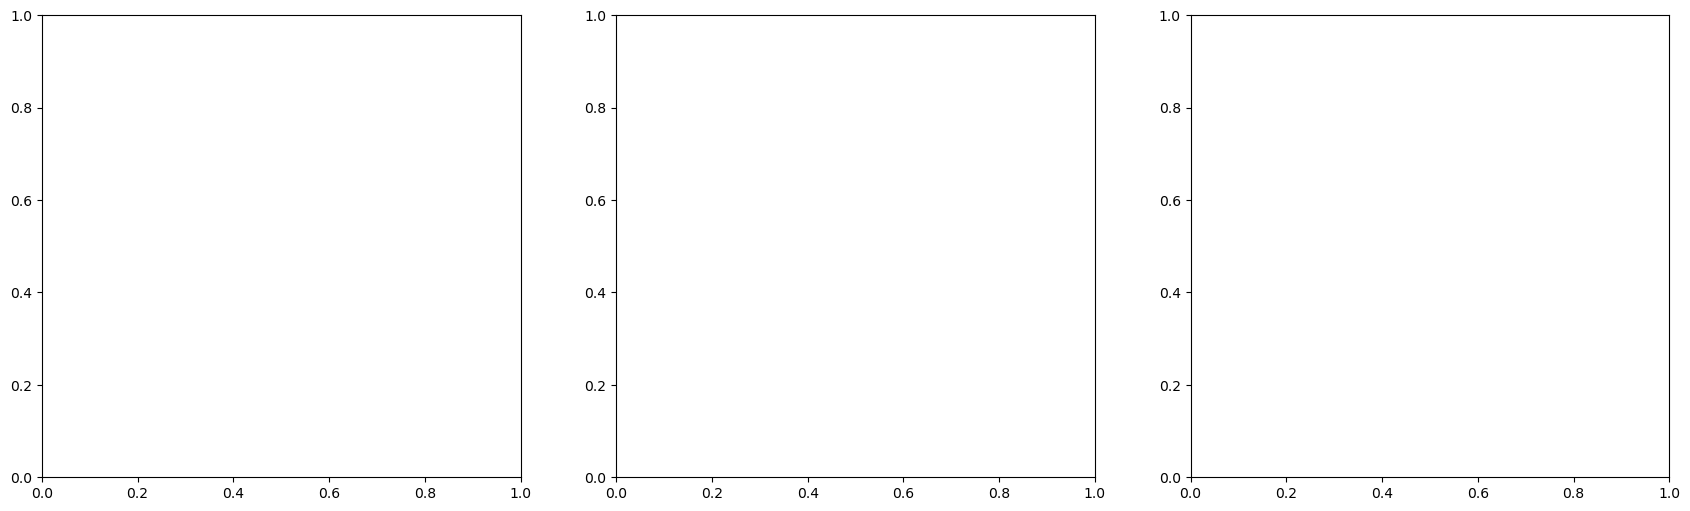

In [3]:
#scatter plots
import numpy as np
import matplotlib.pyplot as plt

years = ["1985-01-01", "2000-01-01", "2024-01-01"]

fig, ax = plt.subplots(1, 3, figsize=(21, 6))

for i, year in enumerate(years):

    # select year
    ds_year = ds_cube.sel(time=year)

    # flatten
    ndvi = ds_year["ndvi"].values.flatten()
    lst = ds_year["lst"].values.flatten()

    # mask invalid values
    mask = (
        np.isfinite(ndvi) &
        np.isfinite(lst) &
        (ndvi > 0) &
        (ndvi < 0.9) &
        (lst > 20) &
        (lst < 50)
    )

    ndvi_clean = ndvi[mask]
    lst_clean = lst[mask]

    # subsample
    idx = np.random.choice(len(ndvi_clean), size=15000, replace=False)
    x = ndvi_clean[idx]
    y = lst_clean[idx]

    # regression
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(0, 0.9, 100)
    y_line = slope * x_line + intercept

    # correlation
    corr = np.corrcoef(x, y)[0, 1]
    r2 = corr**2

    # plot
    ax[i].scatter(x, y, s=2, alpha=0.15)
    ax[i].plot(x_line, y_line, color="red", linewidth=3)

    ax[i].set_title(f"NDVI–LST Relationship ({year[:4]})")
    ax[i].set_xlabel("NDVI")
    ax[i].set_ylabel("LST (°C)")
    ax[i].grid(True)

    ax[i].text(
        0.02, 0.95,
        f"r = {corr:.2f}\nR² = {r2:.2f}",
        transform=ax[i].transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

plt.tight_layout()
plt.show()